In [1]:
!pip install visionist_client

{'frame_index': 300, 'width': 1920, 'height': 1080, 'boxes': [[153.41000366210938, 447.760009765625, 576.010009765625, 875.27001953125]], 'class_ids': [49], 'labels': ['orange'], 'scores': [0.7139000296592712], 'track_id': [6]}


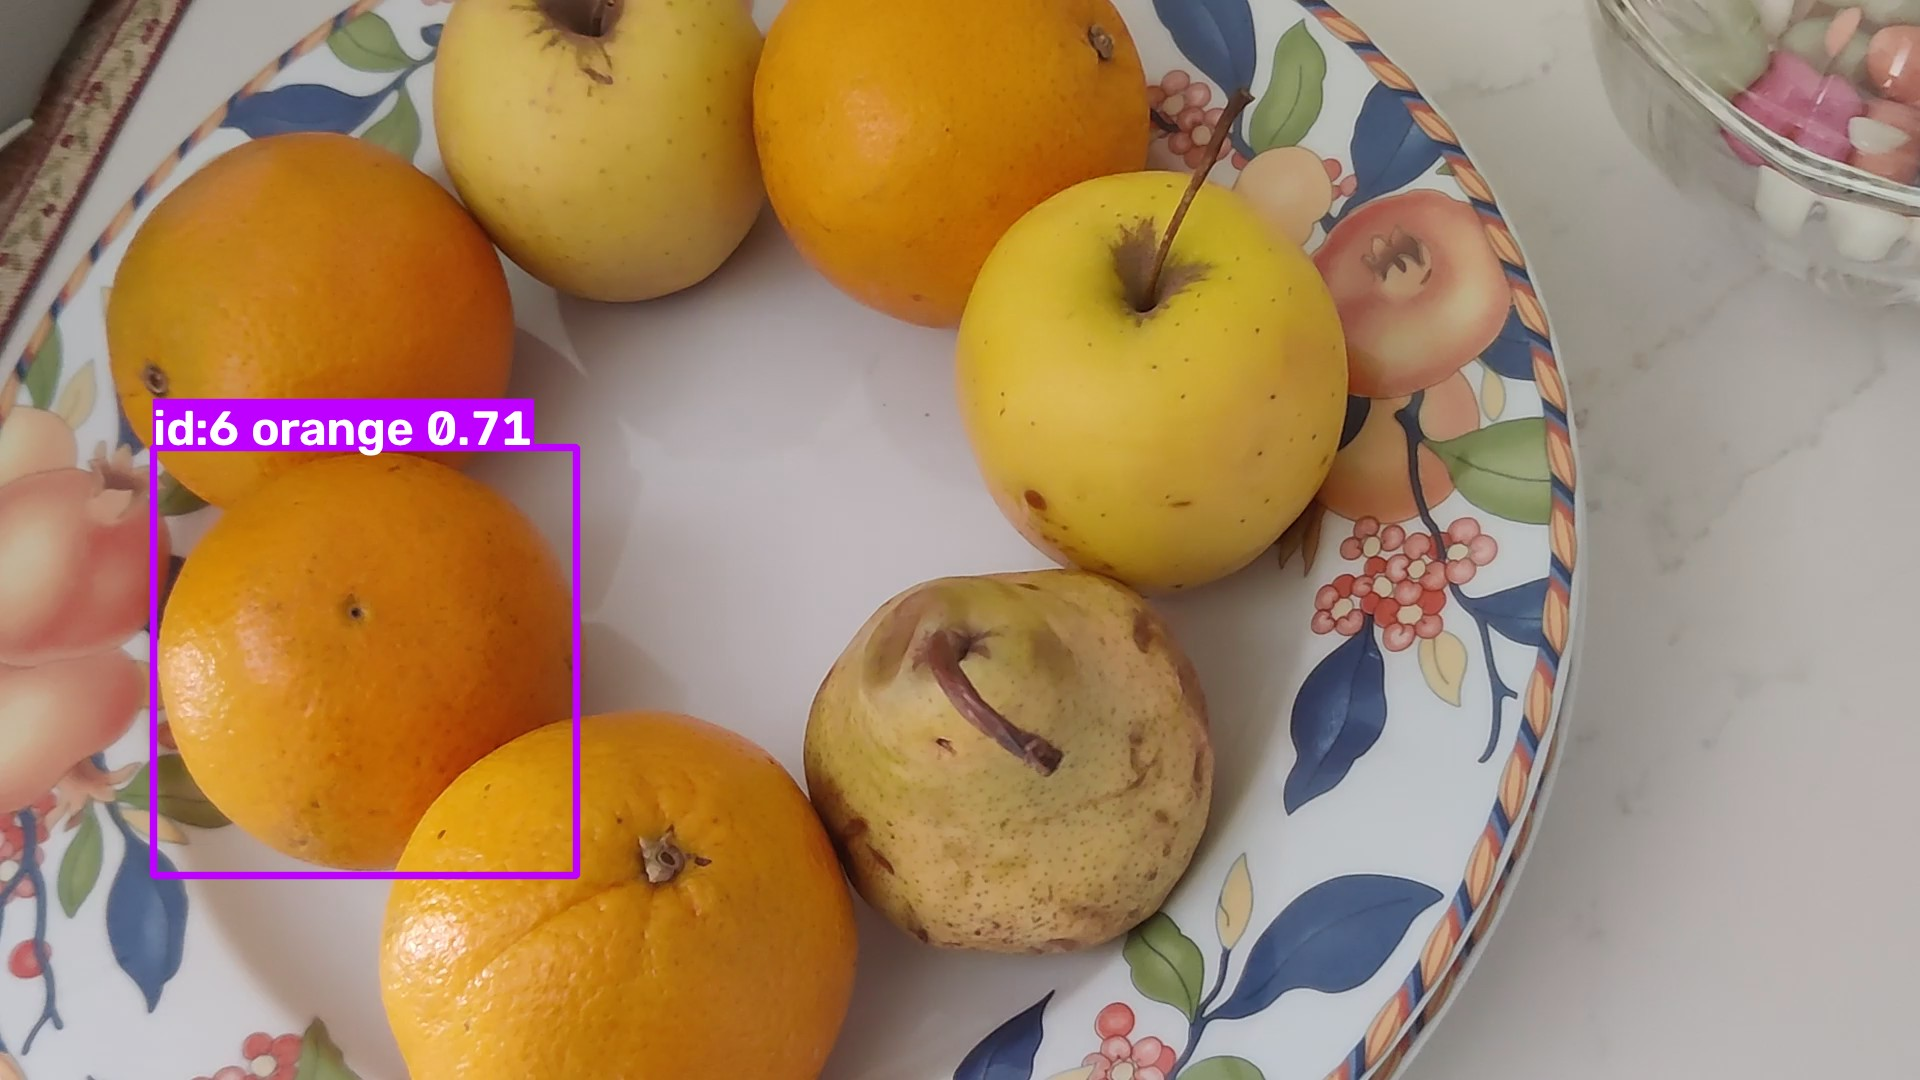

In [2]:
from visionist_client import Visionist
from IPython.display import Video, Image

import pathlib

yolo = Visionist("localhost:9068")

res = yolo.run(
    data   = {"video": pathlib.Path("../cozinha.mp4")},
    config = {"yolo": {"command": "detect",
                       "session_id": "demo-1",
                       "parameters": {"frame_step":30,
                                      "save_annotated": True}}})

print(res.fields["detections"][10])
Image(res.fields["annotated"][10])

In [3]:
from visionist_client import Visionist
from IPython.display import Video, Image

import pathlib

tapnext = Visionist("localhost:9063")

res = tapnext.run(
    data   = {"video": pathlib.Path("../cozinha.mp4")},
    config={"tapnext": {"command": "track",
                          "parameters": {"grid_size": 32},
                          "session_id": "demo-2"}})

res

<Result fields=[observation_matrix, tracks, visibles] config={'tapnext': {'status': 'done', 'session': 'demo-2', 'frames_processed': 302, 'runtime': 10.169309139251709, 'num_points': 1024, 'encoding': {'tracks': 'torch', 'visibles': 'torch', 'observation_matrix': 'torch'}}}>

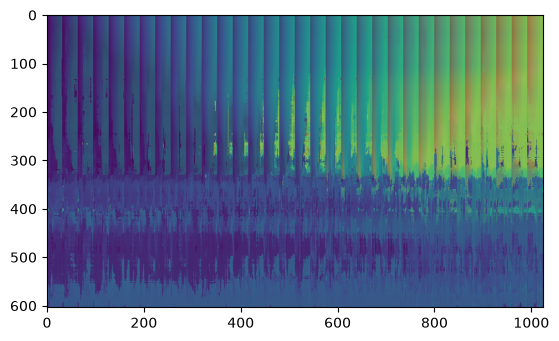

In [4]:
import matplotlib.pyplot as plt
plt.imshow(res.fields["observation_matrix"])


{'lightglue': {'status': 'done', 'matcher': 'LightGlue (superpoint)', 'feature_extractor': 'SUPERPOINT', 'max_keypoints': 1024, 'device': 'cuda', 'num_images': 2, 'num_matches': 314, 'runtime': 0.057007789611816406, 'encoding': {'keypoints': 'numpy', 'descriptors': 'numpy', 'scores': 'numpy', 'matches': 'numpy', 'confidence': 'numpy'}}}
matches: 314 | mean confidence: 0.545


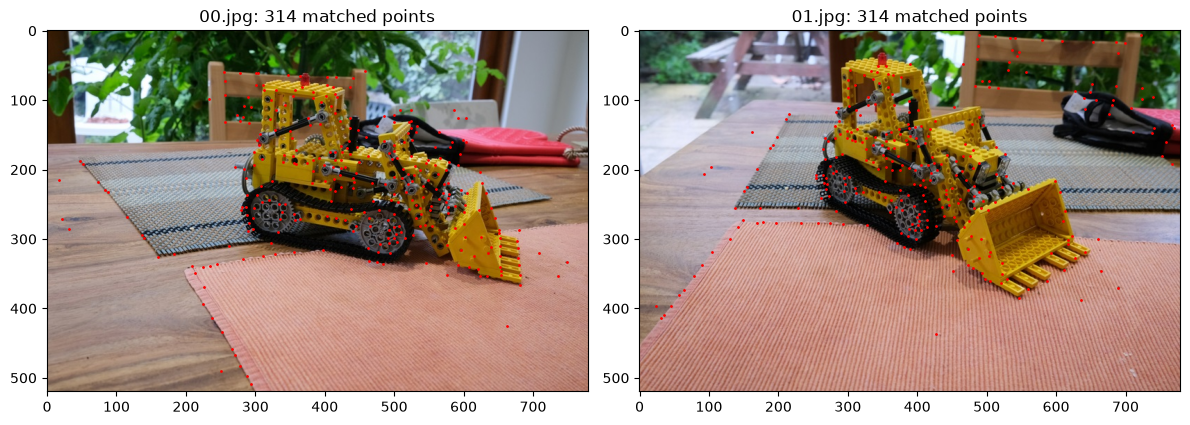

In [5]:
from visionist_client import Visionist
import pathlib
import matplotlib.pyplot as plt

lightglue = Visionist("localhost:9069")   # box-lightglue, mapped 9069 -> 8061

img0 = pathlib.Path("../images/lightglue_box/test/00.jpg")
img1 = pathlib.Path("../images/lightglue_box/test/01.jpg")

res = lightglue.run(
    data   = {"images": [img0, img1]},
    config = {"lightglue": {"parameters": {
        "feature_extractor": "SUPERPOINT",   # or "DISK"
        "max_keypoints": 1024}}})

print(res.config)   # {"lightglue": {"status": "done", "matcher": "LightGlue (superpoint)", …}}

# fields are declared "numpy" — boxes_client hands them back as ndarrays
kp = res.keypoints            # (2, N, 2)
M  = res.matches              # (K, 2) indices — the network's own output
p0 = kp[0][M[:, 0]]           # matched points, image 0
p1 = kp[1][M[:, 1]]           # matched points, image 1
print(f"matches: {len(M)} | mean confidence: {res.confidence.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, pts in zip(axes, (img0, img1), (p0, p1)):
    ax.imshow(plt.imread(str(path)))
    ax.scatter(pts[:, 0], pts[:, 1], s=1, c="red")
    ax.set_title(f"{path.name}: {len(pts)} matched points")
plt.tight_layout()
plt.show()


mode=backbone | min_alive=3 | window=3 | frames=12
union-find components: 1984 (380 glued >1 point into one frame)
tracks kept: 1635 | dropped (< min_alive): 1629 | gap-bridged: 478
tracks per frame: [559, 611, 714, 699, 659, 613, 580, 562, 573, 635, 536, 454]
longest track: 11 frames
obs_matrix: (24, 1635) (2F x tracks); NaN where a point is absent
mode=greedy | min_alive=3 | window=3 | frames=12
union-find components: 1984 (380 glued >1 point into one frame)
tracks kept: 1528 | dropped (< min_alive): 2187 | gap-bridged: 0
tracks per frame: [473, 567, 680, 646, 599, 537, 501, 502, 533, 605, 493, 396]
longest track: 11 frames
obs_matrix: (24, 1528) (2F x tracks); NaN where a point is absent


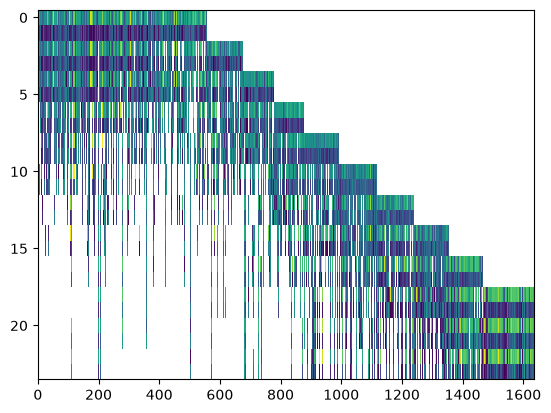

In [7]:
# ---------------------------------------------------------------------------
# lightglue — stream matching across the video -> observation matrix
# The box-side drive + association now come from the convenience layer
# (``visionist_client.track_stream``): it feeds the sampled frames one at a
# time through the box's ``stream`` session (sliding window of ``window``
# stored references), collects the reported ``matches_1..window`` and builds
# the Tomasi-Kanade observation matrix (2F x tracks: x and y per frame, one
# column per tracked point, NaN where absent).  The heavy work — union-find,
# longest-path peeling (one point per frame), min_alive filtering — lives in
# ``visionist_client.tracking`` and is unit-tested there.
# TOGGLE the association with ``mode``: "backbone" (default; Δ=2/3 edges
# re-link a point that blinks for one frame — NaN gap, one track) or
# "greedy" (Δ=1 only; dies + re-births).
# ---------------------------------------------------------------------------
import cv2
import matplotlib.pyplot as plt
from visionist_client import track_stream

N_FRAMES, WINDOW = 12, 3
# drop observation-matrix columns tracked in fewer than this many frames
# (1 = keep everything, 2 = drop one-frame-only features, 3 = drop <=2-frame ones)
MIN_ALIVE = 3
SID = "cozinha-demo"

# evenly spaced sample frames, JPEG-encoded for the box
cap = cv2.VideoCapture("../cozinha.mp4")
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
vid_idx = [int(round(i * (total - 1) / (N_FRAMES - 1))) for i in range(N_FRAMES)]
frames, previews = [], []
for i in vid_idx:
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ok, bgr = cap.read()
    assert ok, f"could not read video frame {i}"
    ok, jpg = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])
    frames.append(jpg.tobytes())
    previews.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
cap.release()

res = track_stream(lightglue, frames, window=WINDOW, min_alive=MIN_ALIVE, session_id=SID)
print(res)
P = res.obs_matrix          # (2*F, tracks)
obs = P.copy()

# the toggle: same box outputs, greedy association (Δ=1 chains, dies + re-births)
res_greedy = track_stream(lightglue, frames, window=WINDOW, min_alive=MIN_ALIVE,
                          mode="greedy", session_id=SID)
print(res_greedy)

plt.imshow(P, aspect="auto", interpolation="none")   # or: res_greedy.obs_matrix

# lightglue.reset("lightglue") to clear the sessions when done


{'unimatch': {'status': 'done', 'command': 'flow', 'model': 'gmflow-scale1-mixdata-train320x576-4c3a6e9a.pth', 'num_images': 2, 'device': 'cuda', 'runtime': 0.06519889831542969, 'encoding': {'flow': 'numpy'}}}
flow (480, 854, 2), mean shift 1.63 px


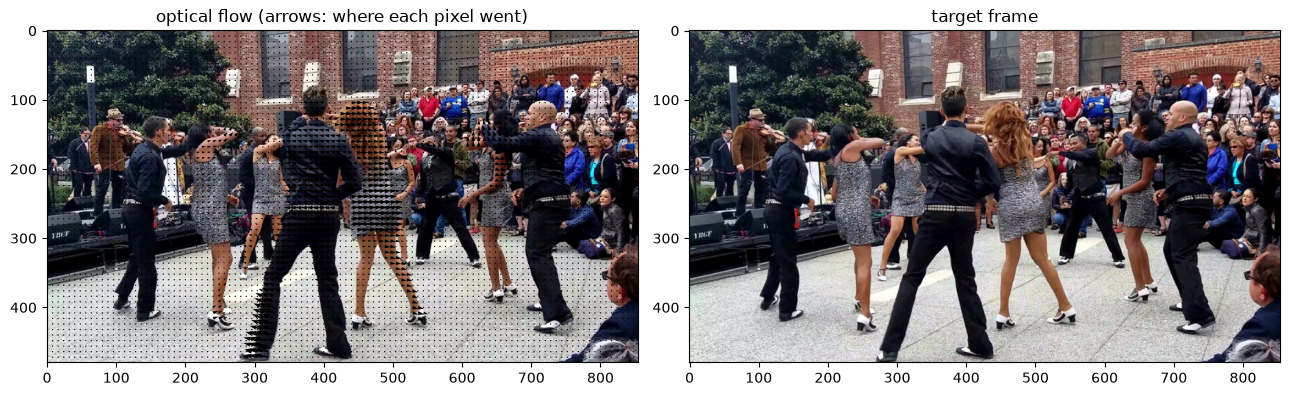

In [8]:
# ---------------------------------------------------------------------------
# unimatch — dense optical flow / stereo disparity / metric depth
# box-unimatch, mapped 9070 -> 8061 (start it: cd fleet && docker compose up -d unimatch)
# ---------------------------------------------------------------------------
from visionist_client import Visionist
import pathlib
import numpy as np
import matplotlib.pyplot as plt

unimatch = Visionist("localhost:9070")

img0 = pathlib.Path("../images/unimatch/test/flow_0.jpg")
img1 = pathlib.Path("../images/unimatch/test/flow_1.jpg")

res = unimatch.run(
    data   = {"images": [img0, img1]},
    config = {"unimatch": {"command": "flow"}})

print(res.config)   # {"unimatch": {"status": "done", …}}

# fields are declared "numpy" — handed back as ndarrays
flow = res.flow     # (H, W, 2): pixel shift of frame 0 -> frame 1
h, w = flow.shape[:2]
print(f"flow {flow.shape}, mean shift {np.linalg.norm(flow, axis=2).mean():.2f} px")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(plt.imread(str(img0)))
xs, ys = np.meshgrid(np.arange(w), np.arange(h))
step = 8                      # draw every Nth arrow
axes[0].quiver(xs[::step, ::step], ys[::step, ::step],
               flow[::step, ::step, 0], flow[::step, ::step, 1], scale=1000)
axes[0].set_title("optical flow (arrows: where each pixel went)")
axes[1].imshow(plt.imread(str(img1)))
axes[1].set_title("target frame")
plt.tight_layout()
plt.show()

{'unimatch': {'status': 'done', 'command': 'stereo', 'model': 'gmstereo-scale1-sceneflow-124a438f.pth', 'num_images': 2, 'device': 'cuda', 'runtime': 0.651738166809082, 'encoding': {'disparity': 'numpy'}}}
disparity (1984, 2840): mean 118.9 | std 76.3 | max 266 px


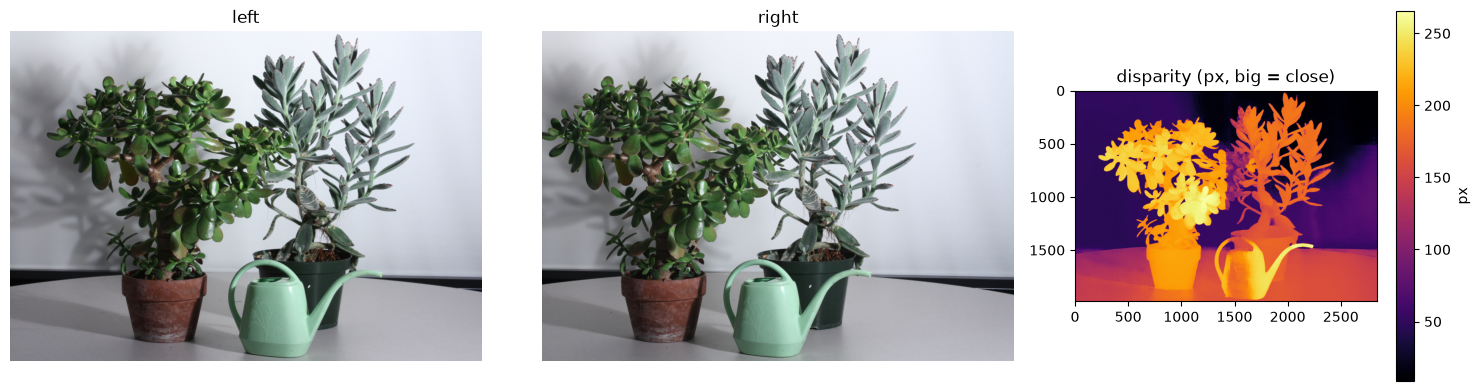

In [9]:
# unimatch — stereo: rectified left/right pair -> per-pixel DISPARITY (px)
#
# Real test pair from the UniMatch repo (Middlebury dataset): a genuine
# left/right view pair of the same scene. (The 2840x1984 originals are heavy —
# `inference_size` downscales inside the box, and the disparity is scaled
# back to full resolution in the response.)
img_l = pathlib.Path("../images/unimatch/test/stereo_0.png")
img_r = pathlib.Path("../images/unimatch/test/stereo_1.png")

res = unimatch.run(
    data   = {"images": [img_l, img_r]},
    config = {"unimatch": {"command": "stereo",
                           "parameters": {
                               # box only ships the flow checkpoint; this fetches
                               # the stereo one once on first call (~19 MB)
                               "model": "https://s3.eu-central-1.amazonaws.com/avg-projects/unimatch/pretrained/gmstereo-scale1-sceneflow-124a438f.pth",
                               "inference_size": [800, 1120]}}})

print(res.config)


d = res.disparity        # (H, W), pixels — bigger = closer
print(f"disparity {d.shape}: mean {d.mean():.1f} | std {d.std():.1f} | max {d.max():.0f} px")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1.25, 1.25, 1]})
axes[0].imshow(plt.imread(str(img_l))); axes[0].axis("off"); axes[0].set_title("left")
axes[1].imshow(plt.imread(str(img_r))); axes[1].axis("off"); axes[1].set_title("right")
im = axes[2].imshow(d, cmap="inferno"); axes[2].set_title("disparity (px, big = close)")
fig.colorbar(im, ax=axes[2], label="px")
fig.tight_layout()
fig.show()

# real use with your stereo camera, rectified frames:
# res = unimatch.run(data={"images": [left_frame, right_frame]},
#                    config={"unimatch": {"command": "stereo",
#                                         "parameters": {"model": "…gmstereo…pth"}}})
# d = res.disparity   # (H, W) px; metric depth ≈ (baseline_m × fx) / d  if calibrated
